# Figure 6

# Setup

## imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cProfile import label

from dms_3d_features.plotting import *

## load data

In [2]:
DATA_PATH = "../../farfar-models"

In [3]:
df = pd.read_csv(f"{DATA_PATH}/csvs/ag_pair_train_analysis.csv")
df_test = pd.read_csv(
    f"{DATA_PATH}/csvs/ag_pair_test_analysis.csv"
)
df_rmsd = pd.read_json(f"{DATA_PATH}/summary/ag_pairs_train_summary.json")
df_test_rmsd = pd.read_json(
    f"{DATA_PATH}/summary/ag_pairs_test_summary.json"
)

# Plotting

## Training 

In [4]:
df_sub = df.query("percent_true_no_cst < 80").copy()
df_test_sub = df_test.query("percent_true_no_cst < 80").copy()
not_well_refined = list(df_sub["motif"])
not_well_refined_test = list(df_test_sub["motif"])

### figure 6a

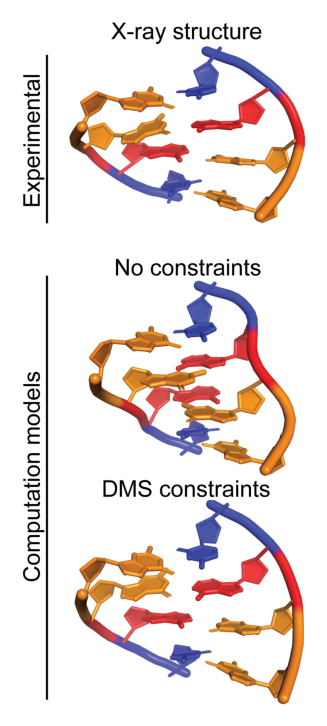

In [5]:
def plot_figure_6a_image_with_annotations(ax, image_path):
    """
    Plots the annotated image for Figure 6a with distance labels and horizontal lines.

    Args:
        image_path (str): Path to the image file.

    Returns:
        tuple: (fig, ax) matplotlib Figure and Axes objects.
    """
    load_and_fit_image_to_subplot(image_path, ax)

# Example usage:
fig, ax = plt.subplots(figsize=(1.65 * 1.35, 3.3 * 1.35), dpi=200)
path = "../../pngs/figure_6a.png"
plot_figure_6a_image_with_annotations(ax, path)

### figure 6b: rmsd funnel

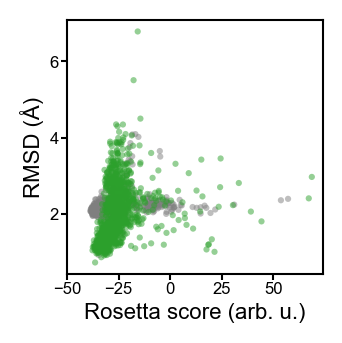

In [6]:
def plot_rosetta_score_vs_rmsd(
    df,
    ax,
    motif="GGAC_GGAC",
    no_constraint_color="tab:gray",
    constraint_color="tab:green",
):
    """
    Plots Rosetta score vs RMSD for all models with and without constraints.

    Args:
        df (pd.DataFrame): DataFrame containing the RMSD data.
        ax (matplotlib.axes.Axes): Axes on which to plot.
        motif (str): Motif to plot.
        no_constraint_color (str): Color for models without constraints.
        constraint_color (str): Color for models with constraints.

    Returns:
        None
    """
    row = df.query("motif == @motif").iloc[0]

    ax.scatter(
        row["no_constraint"]["all_models"]["score"],
        row["no_constraint"]["all_models"]["rmsd"],
        alpha=0.5,
        s=5,
        color=no_constraint_color,
        edgecolors="none",
        marker="o",
        label="No constraint",
    )

    ax.scatter(
        row["with_constraint"]["all_models"]["score"],
        row["with_constraint"]["all_models"]["rmsd"],
        alpha=0.5,
        s=5,
        color=constraint_color,
        edgecolors="none",
        marker="o",
        label="With constraint",
    )

    ax.set_xlabel("Rosetta score (arb. u.)", labelpad=2)
    ax.set_ylabel("RMSD (Å)", labelpad=2)
    ax.set_xticks([-50, -25, 0, 25, 50])

    publication_style_ax(ax)

def plot_rosetta_score_vs_rmsd(
    df,
    ax,
    motif="GGAC_GGAC",
    no_constraint_color="tab:gray",
    constraint_color="tab:green",
):
    """
    Plots Rosetta score vs RMSD for all models with and without constraints.

    Args:
        df (pd.DataFrame): DataFrame containing the RMSD data.
        ax (matplotlib.axes.Axes): Axes on which to plot.
        motif (str): Motif to plot.
        no_constraint_color (str): Color for models without constraints.
        constraint_color (str): Color for models with constraints.

    Returns:
        None
    """
    row = df.query("motif == @motif").iloc[0]

    ax.scatter(
        row["no_constraint"]["all_models"]["score"],
        row["no_constraint"]["all_models"]["rmsd"],
        alpha=0.5,
        s=5,
        color=no_constraint_color,
        edgecolors="none",
        marker="o",
        label="No constraint",
    )

    ax.scatter(
        row["with_constraint"]["all_models"]["score"],
        row["with_constraint"]["all_models"]["rmsd"],
        alpha=0.5,
        s=5,
        color=constraint_color,
        edgecolors="none",
        marker="o",
        label="With constraint",
    )

    ax.set_xlabel("Rosetta score (arb. u.)", labelpad=2)
    ax.set_ylabel("RMSD (Å)", labelpad=2)
    ax.set_xticks([-50, -25, 0, 25, 50])

    publication_style_ax(ax)
    
fig, ax = plt.subplots(figsize=(1.65, 1.65), dpi=200)

plot_rosetta_score_vs_rmsd(
    df_rmsd,
    ax,
    motif="GGAC_GGAC",
)


### figure 6c: rmsd comparision

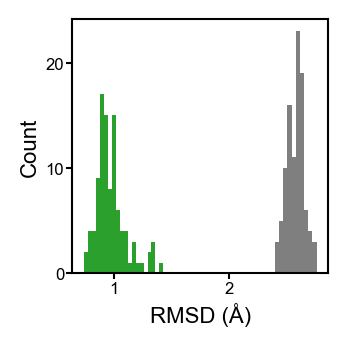

In [7]:
def plot_rmsd_histogram_top100(
    df,
    ax,
    motif="GGAC_GGAC",
    bins_with_constraint=20,
    bins_no_constraint=10,
    with_constraint_color="tab:green",
    no_constraint_color="tab:gray",
):
    """
    Plots RMSD histograms for the top 100 Rosetta models with and without constraints.

    Args:
        df (pd.DataFrame): DataFrame containing the RMSD data.
        ax (matplotlib.axes.Axes): Axes on which to plot.
        motif (str): Motif to plot.
        bins_with_constraint (int): Number of bins for constrained models.
        bins_no_constraint (int): Number of bins for unconstrained models.
        with_constraint_color (str): Color for constrained models.
        no_constraint_color (str): Color for unconstrained models.

    Returns:
        None
    """
    row = df.query("motif == @motif").iloc[0]

    ax.hist(
        row["with_constraint"]["top100_models"]["rmsd"],
        bins=bins_with_constraint,
        color=with_constraint_color,
    )

    ax.hist(
        row["no_constraint"]["top100_models"]["rmsd"],
        bins=bins_no_constraint,
        color=no_constraint_color,
    )

    ax.set_xlabel("RMSD (Å)", labelpad=2)
    ax.set_ylabel("Count", labelpad=2)

    publication_style_ax(ax)
    
fig, ax = plt.subplots(figsize=(1.65, 1.65), dpi=200)

plot_rmsd_histogram_top100(
    df_rmsd,
    ax,
    motif="GGAC_GGAC",
)

### figure 6d: native bp type recovery for train set

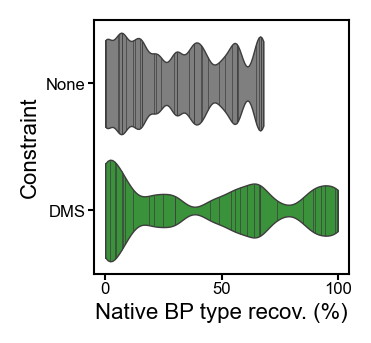

In [8]:
def plot_native_bp_recovery_violin(df, ax):
    """
    Plots violin plots of native base-pair type recovery for models
    with and without DMS constraints.

    Args:
        df (pd.DataFrame): DataFrame containing the recovery statistics.
        ax (matplotlib.axes.Axes): Axes on which to plot.

    Returns:
        None
    """
    df_long = df.melt(
        id_vars="motif",
        value_vars=["percent_true_with_cst", "percent_true_no_cst"],
        var_name="type",
        value_name="accuracy",
    )

    df_long["Constraint"] = df_long["type"].map(
        {
            "percent_true_with_cst": "DMS",
            "percent_true_no_cst": "None",
        }
    )

    colors = {
        "None": "tab:gray",
        "DMS": "tab:green",
    }

    sns.violinplot(
        x="accuracy",
        y="Constraint",
        data=df_long,
        hue="Constraint",
        order=["None", "DMS"],
        palette=colors,
        linewidth=0.5,
        cut=0,
        bw_adjust=0.25,
        inner="stick",
        inner_kws=dict(linewidth=0.25),
        ax=ax,
        legend=False,
    )

    ax.set_xlabel("Native BP type recov. (%)", labelpad=2)
    ax.set_ylabel("Constraint", labelpad=2)

    publication_style_ax(ax)
    
fig, ax = plt.subplots(figsize=(1.65, 1.65), dpi=200)

plot_native_bp_recovery_violin(df_sub, ax)

### figure 6d: rmsd of G-A pairs for train set

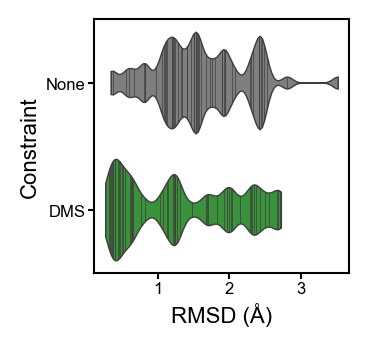

In [9]:
def plot_mean_rmsd_violin_not_well_refined(df, not_well_refined, ax):
    """
    Plots violin plots of mean RMSD for motifs that are not well refined,
    comparing models with and without DMS constraints.

    Args:
        df (pd.DataFrame): DataFrame containing the RMSD data.
        not_well_refined (list): List of motif names to include.
        ax (matplotlib.axes.Axes): Axes on which to plot.

    Returns:
        None
    """
    data = []

    # DMS-constrained models
    for _, row in df.iterrows():
        if row["motif"] not in not_well_refined:
            continue

        for key, pair in row["with_constraint"].items():
            if not key.startswith("pair"):
                continue
            if pair["mean_rmsd"] > 4:
                continue
            data.append([pair["mean_rmsd"], "DMS"])

    # Unconstrained models
    for _, row in df.iterrows():
        if row["motif"] not in not_well_refined:
            continue

        for key, pair in row["no_constraint"].items():
            if not key.startswith("pair"):
                continue
            data.append([pair["mean_rmsd"], "None"])

    df_compare = pd.DataFrame(data, columns=["RMSD", "Constraint"])

    colors = {
        "None": "tab:gray",
        "DMS": "tab:green",
    }

    sns.violinplot(
        x="RMSD",
        y="Constraint",
        data=df_compare,
        hue="Constraint",
        order=["None", "DMS"],
        palette=colors,
        linewidth=0.5,
        cut=0,
        bw_adjust=0.25,
        inner="stick",
        inner_kws=dict(linewidth=0.25),
        legend=False,
        ax=ax,
    )

    ax.set_xlabel("RMSD (Å)", labelpad=2)
    ax.set_ylabel("Constraint", labelpad=2)

    publication_style_ax(ax)
    
fig, ax = plt.subplots(figsize=(1.65, 1.65), dpi=200)

plot_mean_rmsd_violin_not_well_refined(
    df_rmsd,
    not_well_refined,
    ax,
)

## Test

### figure 6e: native bp type recovery of G-A pairs for test set

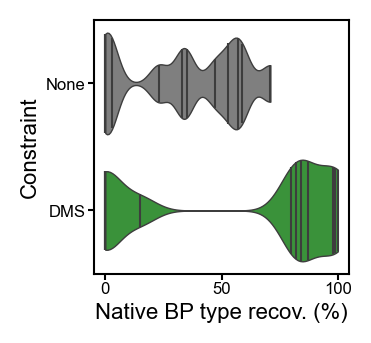

In [10]:
def plot_native_bp_recovery_violin_test(df, ax):
    """
    Plots violin plots of native base-pair type recovery for the test set,
    comparing models with and without DMS constraints.

    Args:
        df (pd.DataFrame): DataFrame containing the test-set recovery statistics.
        ax (matplotlib.axes.Axes): Axes on which to plot.

    Returns:
        None
    """
    df_long = df.melt(
        id_vars="motif",
        value_vars=["percent_true_with_cst", "percent_true_no_cst"],
        var_name="type",
        value_name="accuracy",
    )

    df_long["type"] = df_long["type"].map(
        {
            "percent_true_with_cst": "DMS",
            "percent_true_no_cst": "None",
        }
    )

    colors = {
        "None": "tab:gray",
        "DMS": "tab:green",
    }

    sns.violinplot(
        x="accuracy",
        y="type",
        data=df_long,
        hue="type",
        order=["None", "DMS"],
        palette=colors,
        linewidth=0.5,
        cut=0,
        bw_adjust=0.25,
        inner="stick",
        inner_kws=dict(linewidth=0.75),
        legend=False,
        ax=ax,
    )

    ax.set_xlabel("Native BP type recov. (%)", labelpad=2)
    ax.set_ylabel("Constraint", labelpad=2)

    publication_style_ax(ax)
    
fig, ax = plt.subplots(figsize=(1.65, 1.65), dpi=200)

plot_native_bp_recovery_violin_test(
    df_test_sub,
    ax,
)

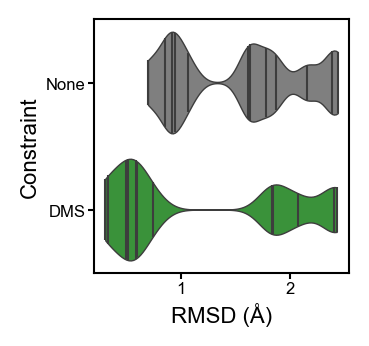

In [11]:
def plot_mean_rmsd_violin_not_well_refined_test(
    df,
    not_well_refined,
    ax,
):
    """
    Plots violin plots of mean RMSD for not well-refined test motifs,
    comparing models with and without DMS constraints.

    Args:
        df (pd.DataFrame): DataFrame containing the test RMSD data.
        not_well_refined (list): List of motifs to include.
        ax (matplotlib.axes.Axes): Axes on which to plot.

    Returns:
        None
    """
    data = []

    # DMS-constrained models
    for _, row in df.iterrows():
        if row["motif"] not in not_well_refined:
            continue

        for key, pair in row["with_constraint"].items():
            if key.startswith("pair"):
                data.append([pair["mean_rmsd"], "DMS"])

    # Unconstrained models
    for _, row in df.iterrows():
        if row["motif"] not in not_well_refined:
            continue

        for key, pair in row["no_constraint"].items():
            if key.startswith("pair"):
                data.append([pair["mean_rmsd"], "None"])

    df_compare = pd.DataFrame(data, columns=["RMSD", "Constraint"])

    colors = {
        "None": "tab:gray",
        "DMS": "tab:green",
    }

    sns.violinplot(
        x="RMSD",
        y="Constraint",
        data=df_compare,
        hue="Constraint",
        order=["None", "DMS"],
        palette=colors,
        linewidth=0.5,
        cut=0,
        bw_adjust=0.25,
        inner="stick",
        inner_kws=dict(linewidth=0.75),
        legend=False,
        ax=ax,
    )

    ax.set_xlabel("RMSD (Å)", labelpad=2)
    ax.set_ylabel("Constraint", labelpad=2)

    publication_style_ax(ax)
    
fig, ax = plt.subplots(figsize=(1.65, 1.65), dpi=200)

plot_mean_rmsd_violin_not_well_refined_test(
    df_test_rmsd,
    not_well_refined_test,
    ax,
)

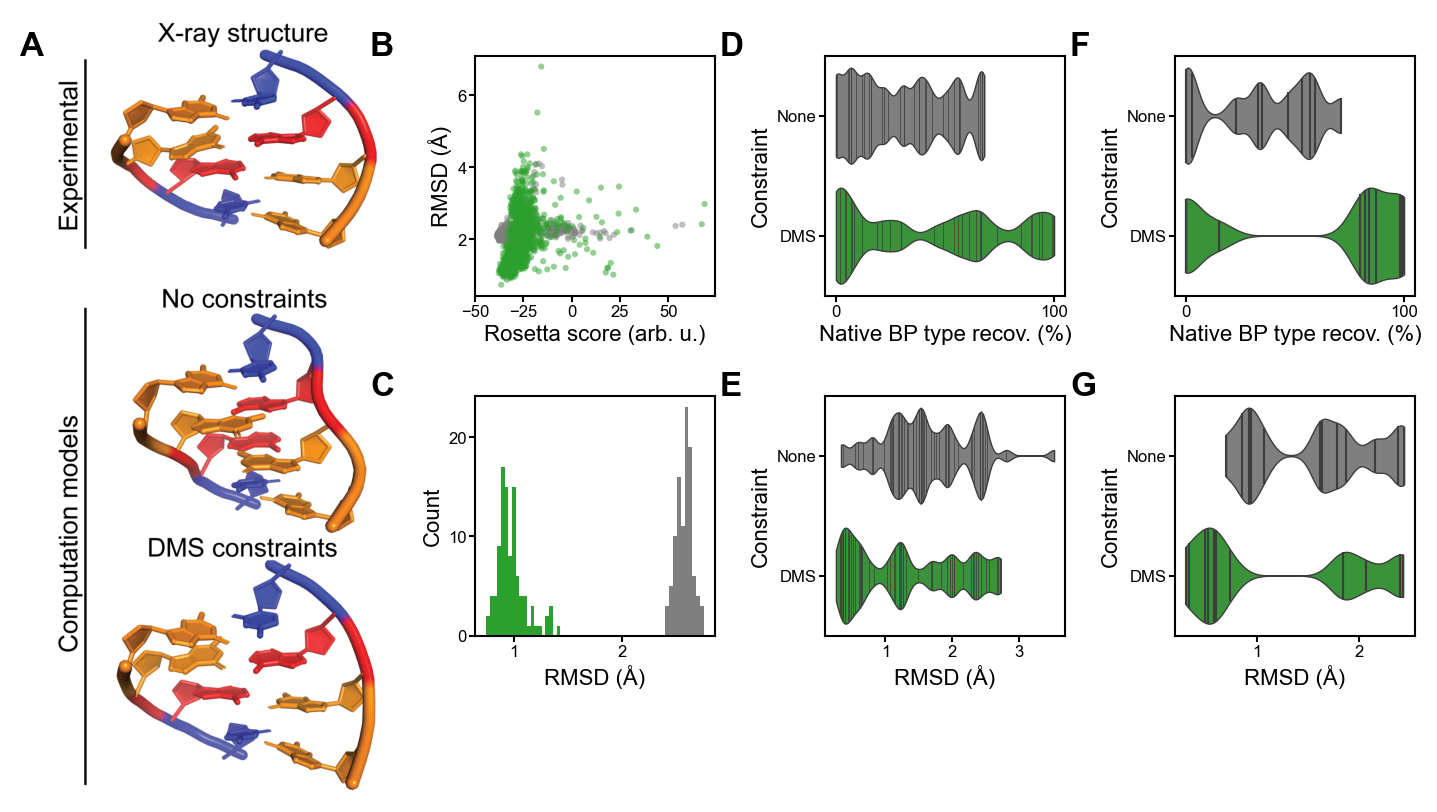

In [12]:
fig_size = (7, 6)
layout = (2, 4)
subplot_size = (1.2, 1.2)  # Each subplot is 4" x 3"
spacing = {
    "hspace": 0.55,  # horizontal spacing in inches
    "wspace": 0.50,  # vertical spacing in inches
    "margins": {"left": 0.50, "right": 0.0, "top": 0.0, "bottom": 0.70},
}

fig = plt.figure(figsize=fig_size, dpi=200)
coords_list = calculate_subplot_coordinates(fig_size, layout, subplot_size, spacing)
coords_list = merge_neighboring_coords(coords_list, [0, 4])
coords_list = [
    coords_list[0],
    coords_list[1],
    coords_list[4],
    coords_list[2],
    coords_list[5],
    coords_list[3],
    coords_list[6]
]

axes = []
for coord in coords_list:
    if coord == coords_list[0]:
        adjusted_coords = adjust_subplot_size(coord, 1.35)
        adjusted_coords = shift_subplot_center(adjusted_coords, dx=-0.020, dy=-0.050)
        ax = fig.add_axes(adjusted_coords)
    else:
        ax = fig.add_axes(coord)
    axes.append(ax)

plot_figure_6a_image_with_annotations(axes[0], "../../pngs/figure_6a.png")

plot_rosetta_score_vs_rmsd(
    df_rmsd,
    axes[1],
    motif="GGAC_GGAC",
)

plot_rmsd_histogram_top100(
    df_rmsd,
    axes[2],
    motif="GGAC_GGAC",
)

plot_native_bp_recovery_violin(df_sub, axes[3])

plot_mean_rmsd_violin_not_well_refined(
    df_rmsd,
    not_well_refined,
    axes[4],
)

plot_native_bp_recovery_violin_test(
    df_test_sub,
    axes[5],
)

plot_mean_rmsd_violin_not_well_refined_test(
    df_test_rmsd,
    not_well_refined_test,
    axes[6],
)

add_subplot_labels(fig, coords_list, left_offset=0.075)

fig.savefig("../../pngs/figures/figure_6.png", dpi=600, bbox_inches="tight")